In [79]:
import datetime as dt
from dateutil.rrule import rrule, MONTHLY
import duckdb
import matplotlib.pyplot as plt

In [23]:
project_root_path = "../../"
customers_path = project_root_path + "data/customers.parquet"

In [24]:
# Load customers table
customers = duckdb.read_parquet(customers_path)

In [ ]:
# Sales
purchase = duckdb.sql("SELECT * FROM customers WHERE event_type = 'purchase'")

# Number of customer per day
nb = duckdb.sql("""
SELECT
    DATE(event_time) AS day,
    COUNT(DISTINCT user_id) AS customer
FROM purchase
GROUP BY day
ORDER BY day
""").fetchnumpy()

# Total sales per month
tt = duckdb.sql("""
SELECT
    DATE_TRUNC('month', event_time) + INTERVAL 14 DAY AS month,
    CAST(SUM(price) AS DECIMAL(9,2)) AS sales
FROM purchase
GROUP BY month
ORDER BY month
""").fetchnumpy()

# Average sales per customer per day
avg = duckdb.sql("""
SELECT
    DATE(event_time) AS day,
    (SUM(price) / NULLIF(COUNT(DISTINCT user_id), 0))::DECIMAL(9,2) AS sales_per_customer
FROM purchase
GROUP BY day
ORDER BY day
""").fetchnumpy()


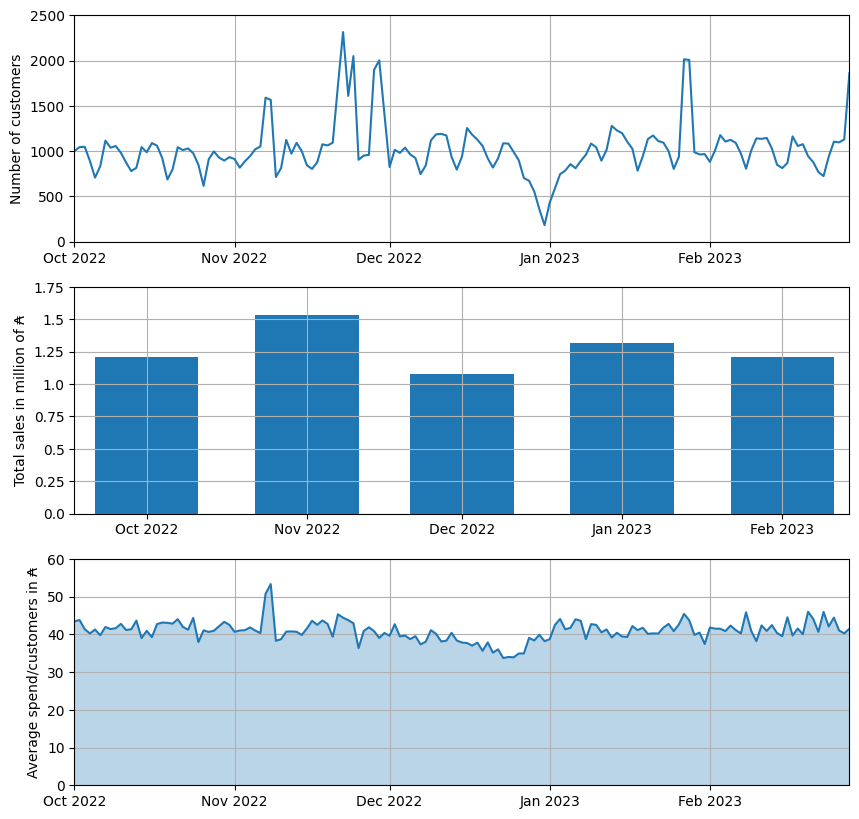

In [115]:
bar_xticks = list(rrule(freq=MONTHLY, dtstart=dt.datetime(2022, 10, 15), until=dt.datetime(2023, 2, 15)))
bar_xtickslabels = [date.strftime("%b %Y") for date in bar_xticks]

plot_xticks = list(rrule(freq=MONTHLY, dtstart=dt.datetime(2022, 10, 1), until=dt.datetime(2023, 2, 1)))
plot_xtickslabels = [date.strftime("%b %Y") for date in plot_xticks]


fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Number of customer per day
axs[0].plot(nb['day'], nb['customer'])
axs[0].set_ylabel('Number of customers')
axs[0].set_xticks(plot_xticks)
axs[0].set_xticklabels(plot_xtickslabels)
axs[0].set_ylim(ymin=0, ymax=2500)

# Total sales per month
axs[1].bar(tt['month'], tt['sales'], width=dt.timedelta(days=20))
axs[1].set_ylabel('Total sales in million of ₳')
axs[1].set_xticks(bar_xticks)
axs[1].set_xticklabels(bar_xtickslabels)
axs[1].set_ylim(ymin=0, ymax=1.75e6)
axs[1].set_yticks(axs[1].get_yticks())
axs[1].set_yticklabels(axs[1].get_yticks() / 1e6)

# Average sales per customer per day
axs[2].plot(avg['day'], avg['sales_per_customer'])
axs[2].fill_between(avg['day'], 0, avg['sales_per_customer'], alpha=0.3)
axs[2].set_ylabel('Average spend/customers in ₳')
axs[2].set_xticks(plot_xticks)
axs[2].set_xticklabels(plot_xtickslabels)
axs[2].set_ylim(ymin=0, ymax=60)

# Axis formatting
for ax in axs:
    ax.grid()
    ax.set_xlim(xmin=dt.datetime(2022, 10, 1), xmax=dt.datetime(2023, 2, 28))

plt.show()